## **The Markov Blanket : a roadmap toward feature selection with causality**

This notebook builds on the **light tunnel** Causal Chamber of Gamella, Peters & Bühlmann (2024).

It uses a **synthetic stand-in dataset**, generated from a
hand-built structural causal model (SCM) designed to mirror the light tunnel's actual physical
structure as described in the paper: a light source (R, G, B) feeds a first sensor (V1, I1);
auxiliary LEDs (L11, L12) contribute weakly and non-linearly there; a first polarizer (theta1)
attenuates the signal reaching a second sensor (V2, I2), with more LEDs (L21, L22) added; a
second polarizer (theta2) attenuates the signal reaching a third sensor (V3, I3), with LEDs
(L31, L32) added there. We also include a nuisance variable `Z_V1` (standing in for the real
system's sensor exposure time) that affects `V1` but **not** `I1` — used later to reproduce the
report's finding that a model relying on a merely-correlated predictor can be broken by an
intervention the causal predictors never see.

In [ ]:
!pip install -q --break-system-packages scikit-learn networkx scipy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
from sklearn.linear_model import LinearRegression

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100

## **Data generation**

In [ ]:
def sample_environment(n, rng, intervene=None):
    """Draw n samples from the light-tunnel SCM. `intervene` optionally overrides one
    variable's sampling range -- this is how we simulate the report's single-target
    interventions (Table 1: e.g. 'uniform_red_mid' shifts R's marginal only)."""
    intervene = intervene or {}

    def u(name, lo, hi):
        if name in intervene:
            lo, hi = intervene[name]
        return rng.uniform(lo, hi, n)

    R = u('R', 0, 85); G = u('G', 0, 85); B = u('B', 0, 85)
    L11 = u('L11', 0, 170); L12 = u('L12', 0, 170)
    L21 = u('L21', 0, 170); L22 = u('L22', 0, 170)
    L31 = u('L31', 0, 170); L32 = u('L32', 0, 170)
    theta1 = u('theta1', -15, 25); theta2 = u('theta2', -15, 25)
    Z_V1 = u('Z_V1', 0.8, 1.2)
    noise = lambda scale: rng.normal(0, scale, n)

    I1 = 12*R + 6*G + 3*B + 0.02*np.exp(L11/60) + 0.02*np.exp(L12/60) + noise(60)
    V1 = 9*R + 10*G + 2*B + Z_V1*180 + noise(60)

    atten1 = 0.5 + 0.5*np.cos(np.deg2rad(2*theta1))
    I2 = 0.9*I1*atten1 + 0.05*L21 + 0.05*L22 + noise(50)
    V2 = 0.9*V1*atten1 + 0.05*L21 + 0.05*L22 + noise(50)

    atten2 = 0.5 + 0.5*np.cos(np.deg2rad(2*theta2))
    I3 = 0.9*I2*atten2 + 0.05*L31 + 0.05*L32 + noise(45)
    V3 = 0.9*V2*atten2 + 0.05*L31 + 0.05*L32 + noise(45)

    return pd.DataFrame({
        'R': R, 'G': G, 'B': B, 'L11': L11, 'L12': L12, 'L21': L21, 'L22': L22,
        'L31': L31, 'L32': L32, 'theta1': theta1, 'theta2': theta2, 'Z_V1': Z_V1,
        'V1': V1, 'V2': V2, 'V3': V3, 'I1': I1, 'I2': I2, 'I3': I3,
    })

In [ ]:
TRUE_PARENTS = {
    'I1': {'R', 'G', 'B', 'L11', 'L12'},
    'V1': {'R', 'G', 'B', 'Z_V1'},
    'I2': {'I1', 'theta1', 'L21', 'L22'},
    'V2': {'V1', 'theta1', 'L21', 'L22'},
    'I3': {'I2', 'theta2', 'L31', 'L32'},
    'V3': {'V2', 'theta2', 'L31', 'L32'},
}
TRUE_EDGES = {frozenset({p, c}) for c, ps in TRUE_PARENTS.items() for p in ps}

rng_master = np.random.default_rng(0)
df_ref = sample_environment(3000, rng_master)
print(f"Reference environment: {df_ref.shape[0]} samples, {df_ref.shape[1]} variables")
df_ref.describe().T[['mean', 'std']].round(2)

Reference environment: 3000 samples, 18 variables


,mean,std
R,42.30,24.59
G,42.48,24.53
B,42.40,24.69
L11,85.54,48.89
L12,86.53,48.79
L21,85.12,48.55
L22,86.94,48.30
L31,83.78,48.44
L32,84.89,49.18
theta1,4.93,11.58


## **The Markov Blanket: concept, toy example, and ground truth**

## **Definition**



For a target variable $Y$ in a DAG $G$ over variables $V$, the **Markov blanket** $MB(Y)$ is the
*minimal* subset of $V \setminus \{Y\}$ such that

$$P(Y \mid V \setminus \{Y\}) = P(Y \mid MB(Y)).$$

In words: once you know $MB(Y)$, learning the value of *any other* variable in the system tells
you nothing more about $Y$. In a DAG, this minimal set has an exact graphical characterization:

$$MB(Y) = \text{Parents}(Y) \;\cup\; \text{Children}(Y) \;\cup\; \text{Spouses}(Y)$$

where **spouses** (co-parents) are the *other* parents of $Y$'s children.

Why does the blanket need children's co-parents and not, say, grandparents? Because a child $C$
of $Y$ is a **collider**: conditioning on $C$ *opens* a path between $Y$ and $C$'s other parents
(this is the "explaining away" effect). So once you condition on children, their co-parents
become newly informative about $Y$ and must be included too. Parents' parents, on the other
hand, only reach $Y$ through $Y$'s parents, who are already in the blanket — no new information.

## **We consider a toy model**

In [ ]:
# Toy graph: A -> Y -> B <- C
G_toy = nx.DiGraph()
G_toy.add_edges_from([('A', 'Y'), ('Y', 'B'), ('C', 'B')])

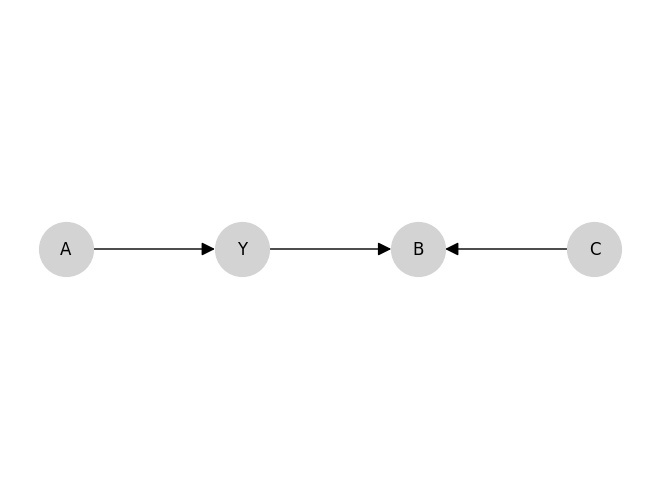

In [ ]:
pos = {'A': (0, 0), 'Y': (1, 0), 'B': (2, 0), 'C': (3, 0)}
nx.draw(G_toy, pos, with_labels=True, node_size=1500,
        node_color='lightgray', arrowsize=20)
plt.show()

## **Calculation of the Markov Blanket of $Y$ on this toy model. Precise parents, children and spouses**

In [ ]:
def markov_blanket(G, y):
    parents = set(G.predecessors(y))
    children = set(G.successors(y))
    spouses = set()
    for c in children:
        spouses |= set(G.predecessors(c)) - {y}
    return parents | children | spouses

In [ ]:
print("Parents(Y):", set(G_toy.predecessors('Y')))
print("Children(Y):", set(G_toy.successors('Y')))
print("MB(Y):", markov_blanket(G_toy, 'Y'))

Parents(Y): {'A'}
Children(Y): {'B'}
MB(Y): {'B', 'A', 'C'}


**Comment:** $MB(Y) = \{A, B, C\}$. The node $C$ *is* in the blanket, even though $C$ has no direct
causal link to $Y$ at all! This is exactly the collider effect described above: once you know
$B$ (a common effect of $Y$ and $C$), $C$ becomes informative about $Y$ (if $B$ is high and $C$
is low, $Y$ was probably high).

## **Question 1 : Compute the true $MB(\tilde I_1)$ for our synthetic system**

We build a `networkx` DiGraph from `TRUE_PARENTS` and read off the blanket mechanically, exactly
as in the toy example above.

In [ ]:
G_true = nx.DiGraph()
G_true.add_nodes_from(set(TRUE_PARENTS.keys()) | set().union(*TRUE_PARENTS.values()))
for child, parents in TRUE_PARENTS.items():
    for p in parents:
        G_true.add_edge(p, child)

In [ ]:
MB_I1_true = markov_blanket(G_true, 'I1')
print("Parents(I1):  ", set(G_true.predecessors('I1')))
print("Children(I1): ", set(G_true.successors('I1')))
print("Spouses(I1):  ", markov_blanket(G_true, 'I1') - set(G_true.predecessors('I1')) - set(G_true.successors('I1')))
print()
print("MB(I1) in THIS synthetic dataset:", sorted(MB_I1_true))


Parents(I1):   {'L11', 'G', 'L12', 'B', 'R'}
Children(I1):  {'I2'}
Spouses(I1):   {'L21', 'theta1', 'L22'}

MB(I1) in THIS synthetic dataset: ['B', 'G', 'I2', 'L11', 'L12', 'L21', 'L22', 'R', 'theta1']


## **Question 2 : Grow-Shrink: a local algorithm for Markov blanket discovery**

We tested two *global* algorithms (PC, GES) that
reconstruct the **entire** DAG, from which $MB(\tilde I_1)$ can then be read off. So why bother
with a second, local-only method?

Two reasons :

1. **Error isolation.** A mistake made by a global algorithm on some *unrelated* part of the
   graph (say, an edge between `theta2` and `L31`) can corrupt the orientation of edges
   elsewhere through cascading rules (recall PC's R1–R4 orientation rules from the reproduction
   notebook — one wrong collider can misorient a chain of downstream edges). A local method
   that only ever asks "is $Y$ independent of variable $Z$ given some conditioning set?" for
   variables *near* $Y$ never has that failure mode.
2. **We don't need the whole graph.** if our goal is the prediction of
   $\tilde I_1$. The Markov blanket is *exactly* the minimal, sufficient covariate set for that recovering the rest of the DAG is wasted effort

## **The algorithm (Grow-Shrink, Margaritis 2003)**

Grow-Shrink has two phases, and it's genuinely simple to state:

- **Growing phase:** start from an empty set $\hat S = \emptyset$. Repeatedly scan all
  variables not yet in $\hat S$; if you find one that is *dependent* on the target given
  $\hat S$, add it. Stop when no such variable remains.
- **Shrinking phase:** now that $\hat S$ is a (possibly bloated) superset of the true blanket,
  remove any variable $Y' \in \hat S$ that turns out to be *conditionally independent* of the
  target given the *rest* of $\hat S$ — i.e. it was only useful because of variables that have
  since joined the set, not because it's really in the blanket.

The growing phase can add spurious variables (order-dependent — an early "lucky" association
that gets explained away later); the shrinking phase is what cleans this up.

## **Conditional independence testing: partial correlation + Fisher's Z**

We shall use tests valid in a **linear Gaussian** setting
so we can test $X \perp Y \mid S$ using the **partial correlation** $\rho_{XY \mid S}$: the
correlation between $X$ and $Y$ after removing the linear effect of $S$ from both (equivalently,
the correlation between the residuals of $X \sim S$ and $Y \sim S$).

We implement this directly below.

In [ ]:
from scipy import stats

def partial_corr(data, x, y, Z):
    '''Partial correlation of x, y given the set Z, via residuals of linear regression.'''
    if len(Z) == 0:
        return np.corrcoef(data[x], data[y])[0, 1]
    Zmat = data[list(Z)].values
    def resid(v):
        beta, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(Zmat)), Zmat]), data[v].values, rcond=None)
        return data[v].values - np.column_stack([np.ones(len(Zmat)), Zmat]) @ beta
    rx, ry = resid(x), resid(y)
    return np.corrcoef(rx, ry)[0, 1]

def fisher_z_test(data, x, y, Z, alpha=0.05):
    '''Fisher's Z conditional-independence test (report's Eq. 3).
    Returns True if we FAIL to reject independence (i.e. we declare X _|_ Y | Z).'''
    n = len(data)
    rho = partial_corr(data, x, y, Z)
    rho = np.clip(rho, -0.999999, 0.999999)  # numerical guard
    k = len(Z)
    if n - k - 3 <= 0:
        return True  # not enough samples to test -- conservatively call independent
    z_stat = 0.5 * np.sqrt(n - k - 3) * np.log((1 + rho) / (1 - rho))
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return p_value > alpha  # True = independent (fail to reject H0)

## **We simulate the toy graph with linear-Gaussian mechanisms to check our CI test against known truth**

In [ ]:
rng_toy = np.random.default_rng(12)
n_toy = 3000
A = rng_toy.normal(size=n_toy)
C = rng_toy.normal(size=n_toy)
Y = 1.5 * A + rng_toy.normal(scale=0.5, size=n_toy)
B = 1.2 * Y + 1.2 * C + rng_toy.normal(scale=0.5, size=n_toy)
toy_df = pd.DataFrame({'A': A, 'Y': Y, 'B': B, 'C': C})

print("Y _|_ C | {}   ->", "INDEPENDENT" if fisher_z_test(toy_df, 'Y', 'C', []) else "DEPENDENT",
      " (expected: INDEPENDENT -- no common cause, no direct edge)")
print("Y _|_ C | {B}  ->", "INDEPENDENT" if fisher_z_test(toy_df, 'Y', 'C', ['B']) else "DEPENDENT",
      " (expected: DEPENDENT -- conditioning on collider B opens the path)")

Y _|_ C | {}   -> INDEPENDENT  (expected: INDEPENDENT -- no common cause, no direct edge)
Y _|_ C | {B}  -> DEPENDENT  (expected: DEPENDENT -- conditioning on collider B opens the path)


This confirms the collider ("explaining away") effect empirically: $Y$ and $C$ look unrelated
until you condition on their shared child $B$, at which point they become dependent — exactly
the mechanism that puts spouses inside the Markov blanket.

## **Grow-Shrink implementation**

In [ ]:
def grow_shrink(data, target, candidates, alpha=0.05, verbose=False):
    '''Algorithm 2 from the report: Grow-Shrink Markov blanket estimation.'''
    S = []
    # --- Growing phase ---
    changed = True
    while changed:
        changed = False
        for var in candidates:
            if var in S or var == target:
                continue
            independent = fisher_z_test(data, target, var, S, alpha=alpha)
            if not independent:  # dependent given current S -> grow
                S.append(var)
                changed = True
                if verbose:
                    print(f"  [grow]   added {var:10s} -> S = {S}")
    # --- Shrinking phase ---
    for var in list(S):
        S_minus = [v for v in S if v != var]
        independent = fisher_z_test(data, target, var, S_minus, alpha=alpha)
        if independent:  # redundant given the rest -> shrink
            S.remove(var)
            if verbose:
                print(f"  [shrink] removed {var:10s} -> S = {S}")
    return set(S)

## **Question 2a : Test this algorithm on the toy graph**

Running GS on our toy dataset should recover exactly $MB(Y) = \{A, B, C\}$

## **Question 2b : Apply Grow-Shrink to the light tunnel, with bootstrap aggregation**

A single run of GS on one dataset can be unstable — the growing phase's outcome depends on scan
order and on which spurious associations happen to look significant in that particular sample.
The report's fix (and ours) is **bootstrap aggregation (bagging)**: resample the dataset with
replacement 100 times, run GS on each resample, and report *how often* each variable is included
across the 100 runs. A variable that's "really" in the blanket should show up almost every time;
a spurious one will appear inconsistently.

## **Scoring against ground truth**

Recall that the *honest* ground truth Markov blanket in **this synthetic dataset**
is $MB(\tilde I_1) = \{R, G, B, L_{11}, L_{12}\} \cup \{I_2\} \cup \{\theta_1, L_{21}, L_{22}\}$
— parents, plus a child, plus that child's co-parents. We score precision/recall/F1 exactly as
in the reproduction notebook.

## **Question 3 : Stability across environments**

The next cell needs several environments, each generated by a single-target intervention that shifts the marginal of one variable. We define them here, then check for each candidate subset how much its regression coefficients vary from one environment to another. A subset whose coefficients stay stable across environments is a good, invariant predictor of $\tilde I_1$.

## **Sample environnements**

In [ ]:
intervention_specs = {
    'reference':        None,
    'uniform_red_mid':  {'R': (30, 55)},
    'uniform_red_high': {'R': (55, 85)},
    'uniform_green_mid':{'G': (30, 55)},
    'uniform_blue_mid': {'B': (30, 55)},
    'theta1_shift':     {'theta1': (5, 25)},
    'Z_V1_shift':       {'Z_V1': (1.2, 1.6)},
    'L21_L22_shift':    {'L21': (100, 170), 'L22': (100, 170)},
}

rng_env = np.random.default_rng(42)
environments = {name: sample_environment(3000, rng_env, intervene=spec)
                for name, spec in intervention_specs.items()}
print(f"{len(environments)} environments:", list(environments))

8 environments: ['reference', 'uniform_red_mid', 'uniform_red_high', 'uniform_green_mid', 'uniform_blue_mid', 'theta1_shift', 'Z_V1_shift', 'L21_L22_shift']


## **Subsets of explicative variables on which we are going to regress**

In [ ]:
stability_subsets = {
    "S'1: {R}":                    ['R'],
    "S'2: {R,G}":                  ['R', 'G'],
    "S'3: {R,B}":                  ['R', 'B'],
    "S'4: {R,G,B} = MB_lin":       ['R', 'G', 'B'],
    "S'5: {R,G,B,V1}":             ['R', 'G', 'B', 'V1'],
    "S'6: {R,G,B,V1,V2}":          ['R', 'G', 'B', 'V1', 'V2'],
    "S'7: {R,G,B,V1,V2,V3}":       ['R', 'G', 'B', 'V1', 'V2', 'V3'],
    "S'8: {R,G,B,I2,I3}":          ['R', 'G', 'B', 'I2', 'I3'],
}

## **Question 3a : Retrain separtely linear regression in each environment for a given subset of explicative variables**

## **Question 3b : Test the stability of regression on each environment for each subset of variables $S$**

## **Question 4 : Predicting $\tilde I_1$ with all variables vs. the Markov blanket**

The point of the Markov blanket is that it is a *sufficient* covariate set: $P(I_1 \mid V\setminus\{I_1\}) = P(I_1 \mid MB(I_1))$. So in principle a model that only sees $MB(I_1)$ should predict as well as one that sees every variable, with fewer features to estimate.

We compare three feature sets for predicting $\tilde I_1$:

- **All variables**: the 16 candidate variables.
- **MB (Grow-Shrink)**: the blanket estimated by Grow-Shrink + bagging above.
- **MB (true)**: the ground-truth blanket read off the DAG (a reference).



In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor

ALL_FEATS  = list(candidate_vars)
GS_FEATS   = sorted(MB_GS_estimated)
TRUE_FEATS = sorted(MB_I1_true)

# **Question 4a : display the list of features corresponding to each set**

Two questions:

1. **In-distribution:** does dropping the non-blanket variables cost accuracy? (We expect no, and a gain when training data is scarce.)
2. **Under distribution shift:** if variables *outside* the blanket change their distribution at test time, is the blanket model more robust?

We use a linear regression and a gradient-boosting model, because the linear model can hide differences that a flexible model reveals.

## **Question 4b : In-distribution prediction (learning curve)**

Train on datasets of increasing size and evaluate on one fixed, large test set drawn from the same environment. Each point is averaged over 20 random training sets.

In [ ]:
def make_model(kind):
    return LinearRegression() if kind == 'linear' else HistGradientBoostingRegressor(max_iter=150, random_state=0)

def rmse(y, yhat):
    return np.sqrt(mean_squared_error(y, yhat))

def fit_eval(train_df, test_df, feats, kind='linear'):
    m = make_model(kind).fit(train_df[feats].values, train_df['I1'].values)
    return rmse(test_df['I1'].values, m.predict(test_df[feats].values))

In [ ]:
rng_pred = np.random.default_rng(100)
test_iid = sample_environment(5000, rng_pred)
train_sizes = [30, 50, 100, 300, 1000, 3000]

## **Question 4c : Prediction under distribution shift**

Now train once on the reference environment and test on environments where a variable **outside** the blanket has a different distribution, using the `intervene` argument of `sample_environment`. Some shifts push the variable beyond its training range, so a model that leans on it has to extrapolate.

- `Z_V1 shifted`: the hidden factor behind `V1` (a non-blanket variable) moves.
- `theta2 shifted`: the second polarizer angle moves.
- `L31, L32 shifted`: the ambient light terms behind `I3`/`V3` move.
- `all combined`: all of the above at once.

In [ ]:
shift_envs = {
    'no shift':         None,
    'Z_V1 shifted':     {'Z_V1': (2.5, 4.0)},
    'theta2 shifted':   {'theta2': (30, 45)},
    'L31, L32 shifted': {'L31': (300, 400), 'L32': (300, 400)},
    'all combined':     {'Z_V1': (2.5, 4.0), 'theta2': (30, 45), 'L31': (300, 400), 'L32': (300, 400)},
}

train_ood = sample_environment(3000, np.random.default_rng(200))